In [1]:
import sys, json, datetime

In [2]:
import pydocmaker as pyd
print(pyd.__version__)

2.6.9


## Export reports to Redmine wiki

### Build example document to upload


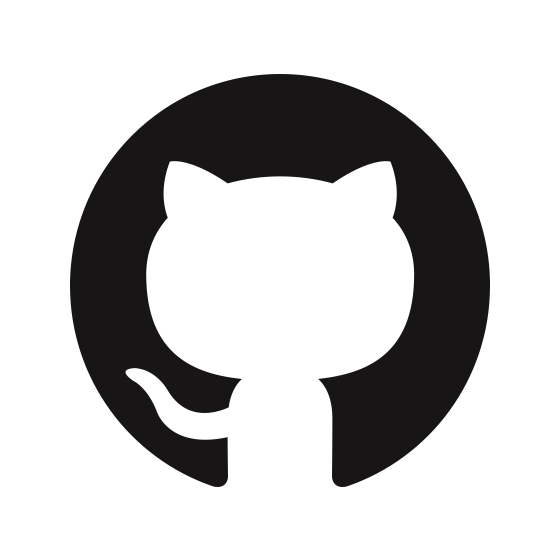

In [3]:
doc = pyd.Doc()
doc.add_chapter('Introduction')
doc.add('dummy text which will be added to the introduction')
doc.add_kw('verbatim', 'def hello_world():\n   print("hello world!")')
doc.add_chapter('Second Chapter')
doc.add_kw('markdown', 'This is my fancy `markdown` text for the Second Chapter')
doc.add_image("https://github.githubassets.com/assets/GitHub-Mark-ea2971cee799.png")
doc.show()

### Define the connection to our Redmine server

In [4]:
import redminelib

# Replace with your Redmine instance URL, and token
my_server = 'https://your-redmine-instance.com'
my_token = 'your_redmine_token'

redmine = redminelib.Redmine(my_server, key=my_token)

redmine

ModuleNotFoundError: No module named 'redminelib'

### The easy way: upload via `.upload_report_to_redmine(...)`

In [ ]:
page = doc.to_redmine_upload(redmine, 'your-test-project')
# page should be the link to your wiki page
page

### The harder way: export and manual upload

In [ ]:
# here we can not save to a file, but only return the exported values
text_textile, attachments_lst = doc.to_redmine()

print(text_textile[:100] + '...\n(rest omitted for brevity)')

print('-'*100)
print('Attachments')
print('-'*100)
for a in attachments_lst:
    print(a.get('filename'), type(a.get('path')), a.get('content_type'))

# this we can use to upload to redmine, but not save to a file directly

page_title = 'My Wiki Page'
project_id = 'myproject'


page = redmine.wiki_page.new()
page.project_id = project_id
page.title = page_title

page.text = text_textile
page.uploads = attachments_lst
page.comments = f'updated at {datetime.datetime.now(tz=datetime.timezone.utc).isoformat()}'
page.save()


print("Wiki page created successfully.")


